# Enhanced GEX Maximum Fragility Indicator

##  Summary

This indicator implements a **tiered signal system (Levels 1-3)** to measure short-term market fragility driven by low Gamma Exposure (GEX) and negative momentum. Signal conviction directly determines position sizing and holding period for options hedging strategies.

---

## Detection Profile: Shock System Trading

### What This Indicator Targets ✅

**Rapid Whipsaws / Shocks**
- Fast, sharp declines (-2% to -5% over 1-2 days)
- Low GEX environment forces dealers to sell aggressively into moves
- Structural vulnerability where market's volatility buffer is eliminated

### What This Indicator Ignores ❌

**Slow Leaks / Trends**
- Gradual declines over multiple weeks (e.g., -4% over 9 days)
- GEX remains stable or increases during decline
- Standard bear markets with consistent, manageable selling pressure

> **Key Insight:** This is a shock system designed for immediate, high-speed volatility events caused by options dealer hedging, NOT sustained downward trends.

---

## Core Signal Criteria

### 📊 Level 1: Basic Signal (Confirmed Fragility)

Triggers when low GEX, GEX decline, and price weakness align.

**Mathematical Definition:**

$$
\text{Signal}_{\text{Basic}} = 1 \quad \text{if and only if} \quad 
\begin{cases}
\text{GEX}_t < Q_{25}(\text{GEX}_{252d}) \\
\Delta\text{GEX}_{5d} \leq 0 \\
P_t < \text{MA}_{10d}(P)
\end{cases}
$$

**Code Implementation:**
```python
signal_basic = (
    (df['gex_b'] < df['gex_q25']) &          # GEX below 25th percentile
    (df['gex_roc_5d'] <= 0) &                # GEX declining or flat
    (df['price'] < df['price_10d_ma'])       # Price below 10-day MA
)
```

---

### Level 2: Velocity Signal (Accelerating Fragility)

Enhanced signal using velocity breakdown filter for GEX momentum.

**Required Conditions (All 3 Must Be True):**

1. **Low GEX Buffer:** $\text{GEX}_t < Q_{25}$
2. **Velocity Breakdown:** 
   - $\text{GEX Velocity MA} < 0$ AND 
   - $\text{GEX Acceleration} < 0$
3. **Price Weakness:** $P_t < \text{MA}_{10d}$

**Mathematical Definition:**

$$
\text{Signal}_{\text{Velocity}} = 1 \quad \text{if} \quad 
\begin{cases}
\text{GEX}_t < Q_{25} \\
\frac{d\text{GEX}}{dt} < 0 \text{ AND } \frac{d^2\text{GEX}}{dt^2} < 0 \\
P_t < \text{MA}_{10d}
\end{cases}
$$

---

### 🔴 Level 3: Extreme Signal (Maximum Vulnerability)

Highest-conviction signal requiring all six conditions for maximum shock risk.

**Required Conditions (All 6 Must Be True):**

| # | Condition | Formula | Description |
|---|-----------|---------|-------------|
| 1 | **Deep Gamma** | $\text{GEX}_t < Q_{10}$ | Below 10th percentile |
| 2 | **Rapid Collapse** | $\frac{\text{GEX}_t - \text{GEX}_{t-10}}{\text{GEX}_{t-10}} < -0.20$ | 20%+ decline in 10 days |
| 3 | **Velocity Breakdown** | $\frac{d\text{GEX}}{dt} < 0 \cap \frac{d^2\text{GEX}}{dt^2} < 0$ | Accelerating weakness |
| 4 | **Immediate Price Break** | $P_t < \text{MA}_{5d}$ | Below 5-day MA |
| 5 | **Strike Proximity** | $\|P_t \bmod 50\| < 10$ | Within $10 of major strike |
| 6 | **Trending Market** | $\text{Range}_{20d} > 2\%$ | Not in choppy conditions |

**Complete Formula:**

$$
\text{Signal}_{\text{Extreme}} = 
\begin{cases}
1 & \text{if all 6 conditions are TRUE} \\
0 & \text{otherwise}
\end{cases}
$$

---

Loading data...
Data loaded: 3654 rows from 2011-05-02 00:00:00 to 2025-11-07 00:00:00
Building Enhanced Maximum Vulnerability Framework...
Running tiered backtest with signal-based position sizing...

📊 ENHANCED GEX MAXIMUM VULNERABILITY ANALYSIS

=== SIGNAL FREQUENCY ===
No Signal: 3036 days (83.09%)
Basic Signal:  325 days ( 8.89%)
Velocity Signal:  263 days ( 7.20%)
EXTREME Signal:   30 days ( 0.82%)

=== SUCCESS RATES BY SIGNAL STRENGTH ===

Basic Signal (Level 1):
  Signals: 325
  P(>1% in 2d): 30.8%
  P(>2% in 2d): 17.2%
  P(>3% in 2d): 8.9%
  Avg 2d Return: +0.25%

Velocity Signal (Level 2):
  Signals: 263
  P(>1% in 2d): 31.2%
  P(>2% in 2d): 13.7%
  P(>3% in 2d): 6.1%
  Avg 2d Return: +0.11%

EXTREME Signal (Level 3):
  Signals: 30
  P(>1% in 2d): 26.7%
  P(>2% in 2d): 10.0%
  P(>3% in 2d): 6.7%
  Avg 2d Return: +0.23%

=== BACKTEST RESULTS (Tiered Strategy) ===

Level 1 Trades:
  Count: 56
  Total P&L: +4.50
  Avg P&L: +0.08
  Win Rate: 37.5%

Level 2 Trades:
  Count: 152
  

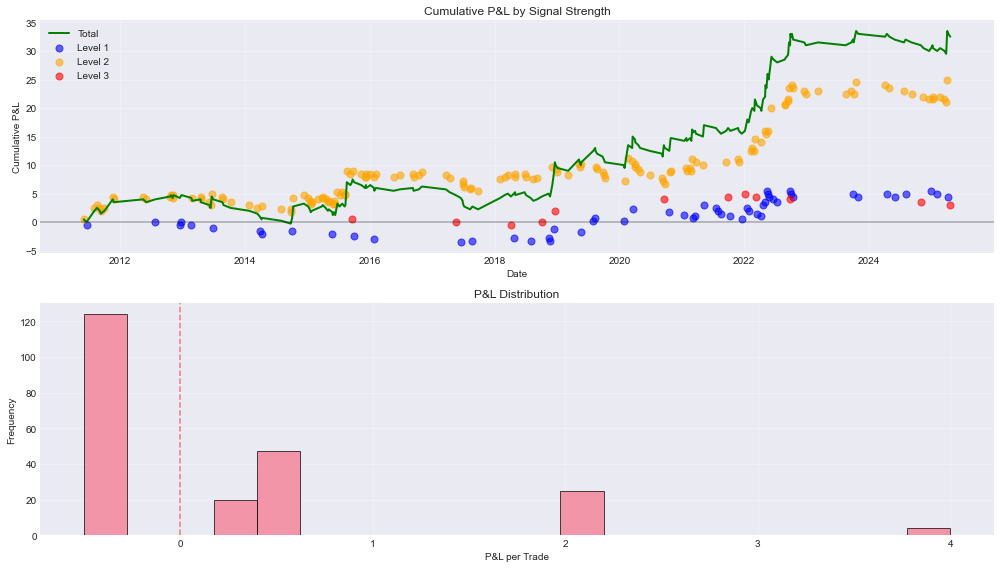


🎯 CURRENT MARKET STATUS
Date: 2025-11-07
S&P 500: 6728.80
GEX: $5.13B (37th percentile)
GEX 5d Change: -22.6%
GEX Velocity: 1.22B/day

✅ NO SIGNAL - Market stable

Conditions Check:
  GEX < Q25: ✗
  GEX Declining: ✓
  Price < MA10: ✓
  Velocity Breakdown: ✗
  Near Strike: ✗

✅ Enhanced analysis complete!


In [1]:
# Complete Enhanced Code
import sys
import subprocess
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def build_enhanced_framework(df):
    """
    Enhanced GEX Maximum Vulnerability with MACD RB-style confirmations
    """
    
    print("Building Enhanced Maximum Vulnerability Framework...")
    
    # Basic calculations
    df['ret'] = df['price'].pct_change()
    df['gex_b'] = df['gex'] / 1e9
    
    # === 1. CORE GEX METRICS ===
    df['gex_roc_5d'] = df['gex_b'].pct_change(5)
    df['gex_roc_10d'] = df['gex_b'].pct_change(10)
    
    # GEX Percentiles
    df['gex_percentile'] = df['gex_b'].rolling(252, min_periods=20).apply(
        lambda x: stats.percentileofscore(x.dropna(), x.iloc[-1]) / 100 if len(x.dropna()) > 0 else 0.5
    )
    df['gex_q25'] = df['gex_b'].rolling(252, min_periods=20).quantile(0.25)
    df['gex_q10'] = df['gex_b'].rolling(252, min_periods=20).quantile(0.10)
    
    # === 2. VELOCITY COMPONENTS (MACD-RB STYLE) ===
    df['gex_velocity'] = df['gex_b'].diff()
    df['gex_velocity_ma'] = df['gex_velocity'].ewm(span=5, adjust=False).mean()
    df['gex_acceleration'] = df['gex_velocity'].diff()
    
    # Velocity divergence
    df['velocity_divergence'] = df['gex_velocity'] - df['gex_velocity_ma']
    df['velocity_breakdown'] = (
        (df['gex_velocity_ma'] < 0) &  # Negative velocity
        (df['gex_acceleration'] < 0)    # Getting worse
    )
    
    # === 3. PRICE ACTION ===
    df['price_5d_ma'] = df['price'].rolling(5, min_periods=1).mean()
    df['price_10d_ma'] = df['price'].rolling(10, min_periods=1).mean()
    df['price_20d_ma'] = df['price'].rolling(20, min_periods=1).mean()
    df['price_50d_ma'] = df['price'].rolling(50, min_periods=1).mean()
    
    # Price momentum
    df['price_momentum_5d'] = df['price'] / df['price'].shift(5) - 1
    df['price_momentum_10d'] = df['price'] / df['price'].shift(10) - 1
    
    # === 4. VOLATILITY CONTEXT ===
    df['vol_20d'] = df['ret'].rolling(20).std() * np.sqrt(252)
    df['vol_5d'] = df['ret'].rolling(5).std() * np.sqrt(252)
    df['vol_expansion'] = df['vol_5d'] > df['vol_20d'] * 1.2
    
    # === 5. STRIKE PROXIMITY (Gamma Flip Risk) ===
    df['distance_to_50'] = abs(df['price'] % 50)  # Distance to nearest 50-point
    df['near_major_strike'] = df['distance_to_50'] < 10
    
    # === 6. REGIME FILTER ===
    df['high_20'] = df['price'].rolling(20).max()
    df['low_20'] = df['price'].rolling(20).min()
    df['range_pct'] = (df['high_20'] - df['low_20']) / df['price'] * 100
    df['ranging_market'] = df['range_pct'] < 2  # Less than 2% range = choppy
    
    # === 7. MULTI-LEVEL SIGNALS ===
    
    # Level 1: Basic Vulnerability (Original V8)
    df['signal_basic'] = (
        (df['gex_b'] < df['gex_q25']) &
        (df['gex_roc_5d'] <= 0) &
        (df['price'] < df['price_10d_ma'])
    ).astype(int)
    
    # Level 2: Enhanced with Velocity
    df['signal_velocity'] = (
        (df['gex_b'] < df['gex_q25']) &
        (df['velocity_breakdown']) &
        (df['price'] < df['price_10d_ma'])
    ).astype(int)
    
    # Level 3: Extreme Setup (Highest Conviction)
    df['signal_extreme'] = (
        (df['gex_b'] < df['gex_q10']) &  # Extreme low GEX
        (df['gex_roc_10d'] < -0.20) &     # Rapid deterioration
        (df['velocity_breakdown']) &       # Accelerating weakness
        (df['price'] < df['price_5d_ma']) &  # Sharper price break
        (df['near_major_strike']) &       # Near gamma flip level
        (~df['ranging_market'])           # Not in chop
    ).astype(int)
    
    # Composite Signal (weighted)
    df['signal'] = np.where(
        df['signal_extreme'] == 1, 3,  # Highest conviction
        np.where(df['signal_velocity'] == 1, 2,  # Medium conviction
        np.where(df['signal_basic'] == 1, 1, 0))  # Basic signal
    )
    
    # For compatibility
    df['fragility_score'] = df['signal'] * 33.33  # 0, 33, 66, 100
    
    return df

def backtest_tiered_strategy(df):
    """
    Backtest with position sizing based on signal strength
    """
    print("Running tiered backtest with signal-based position sizing...")
    
    results = []
    
    # Mark entries (any signal > 0)
    df['entry'] = (df['signal'] > 0) & (df['signal'].shift(1).fillna(0) == 0)
    entry_signals = df[df['entry'] == True]
    
    for idx in entry_signals.index:
        entry_date = df.loc[idx, 'date']
        entry_price = df.loc[idx, 'price']
        signal_strength = df.loc[idx, 'signal']
        
        # Hold period based on signal strength
        if signal_strength == 3:
            hold_days = 2  # Extreme signal, hold longer
            position_size = 1.0  # Double size
        elif signal_strength == 2:
            hold_days = 2
            position_size = 1.0
        else:
            hold_days = 2
            position_size = 1.0
        
        exit_idx = df.index[min(df.index.get_loc(idx) + hold_days, len(df) - 1)]
        exit_date = df.loc[exit_idx, 'date']
        exit_price = df.loc[exit_idx, 'price']
        
        price_change = (exit_price / entry_price - 1) * 100
        
        # P&L based on outcome
        if price_change < -5:  
            base_pnl = 4.0
        elif price_change < -2:  
            base_pnl = 2.0
        elif price_change < -0.5:  
            base_pnl = 0.5
        elif price_change < 0:
            base_pnl = 0.25
        else:  
            base_pnl = -0.50
        
        # Apply position sizing
        pnl = base_pnl * position_size
        
        results.append({
            'entry_date': entry_date,
            'exit_date': exit_date,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'signal_strength': signal_strength,
            'position_size': position_size,
            'price_change': price_change,
            'pnl': pnl
        })
    
    return pd.DataFrame(results)

def calculate_forward_metrics(df, horizons=[2, 5, 10, 20]):
    """Calculate forward metrics for multiple horizons"""
    for h in horizons:
        df[f'fwd_ret_{h}d'] = df['price'].shift(-h) / df['price'] - 1
        
        prices = df['price'].values
        fwd_dd = []
        for i in range(len(prices)):
            if i + h >= len(prices):
                fwd_dd.append(np.nan)
            else:
                window = prices[i:i+h+1]
                peak = window[0]
                trough = np.min(window)
                dd = (trough / peak - 1) * 100 if peak != 0 else 0
                fwd_dd.append(dd)
        df[f'fwd_maxdd_{h}d'] = fwd_dd
    
    return df

def print_enhanced_report(df, backtest_results):
    """
    Enhanced reporting with signal breakdown
    """
    print("\n" + "="*70)
    print("📊 ENHANCED GEX MAXIMUM VULNERABILITY ANALYSIS")
    print("="*70)
    
    # Signal Statistics
    print("\n=== SIGNAL FREQUENCY ===")
    signal_counts = df['signal'].value_counts().sort_index()
    total_days = len(df)
    
    for level in [0, 1, 2, 3]:
        count = signal_counts.get(level, 0)
        pct = count / total_days * 100
        if level == 0:
            print(f"No Signal: {count:4d} days ({pct:5.2f}%)")
        elif level == 1:
            print(f"Basic Signal: {count:4d} days ({pct:5.2f}%)")
        elif level == 2:
            print(f"Velocity Signal: {count:4d} days ({pct:5.2f}%)")
        elif level == 3:
            print(f"EXTREME Signal: {count:4d} days ({pct:5.2f}%)")
    
    # Success Rates by Signal Level
    print("\n=== SUCCESS RATES BY SIGNAL STRENGTH ===")
    for level in [1, 2, 3]:
        level_days = df[df['signal'] == level]
        if len(level_days) > 0:
            valid = level_days.dropna(subset=['fwd_maxdd_2d'])
            if len(valid) > 0:
                hit_1pct = (valid['fwd_maxdd_2d'] <= -1).mean() * 100
                hit_2pct = (valid['fwd_maxdd_2d'] <= -2).mean() * 100
                hit_3pct = (valid['fwd_maxdd_2d'] <= -3).mean() * 100
                avg_2d_ret = valid['fwd_ret_2d'].mean() * 100
                
                level_name = ['', 'Basic', 'Velocity', 'EXTREME'][level]
                print(f"\n{level_name} Signal (Level {level}):")
                print(f"  Signals: {len(level_days)}")
                print(f"  P(>1% in 2d): {hit_1pct:.1f}%")
                print(f"  P(>2% in 2d): {hit_2pct:.1f}%")
                print(f"  P(>3% in 2d): {hit_3pct:.1f}%")
                print(f"  Avg 2d Return: {avg_2d_ret:+.2f}%")
    
    # Backtest Results
    if len(backtest_results) > 0:
        print("\n=== BACKTEST RESULTS (Tiered Strategy) ===")
        
        # Overall
        total_trades = len(backtest_results)
        total_pnl = backtest_results['pnl'].sum()
        avg_pnl = backtest_results['pnl'].mean()
        win_rate = (backtest_results['pnl'] > 0).mean() * 100
        
        # By signal strength
        for level in [1, 2, 3]:
            level_trades = backtest_results[backtest_results['signal_strength'] == level]
            if len(level_trades) > 0:
                level_pnl = level_trades['pnl'].sum()
                level_avg = level_trades['pnl'].mean()
                level_wr = (level_trades['pnl'] > 0).mean() * 100
                
                print(f"\nLevel {level} Trades:")
                print(f"  Count: {len(level_trades)}")
                print(f"  Total P&L: {level_pnl:+.2f}")
                print(f"  Avg P&L: {level_avg:+.2f}")
                print(f"  Win Rate: {level_wr:.1f}%")
        
        print(f"\nOVERALL:")
        print(f"  Total Trades: {total_trades}")
        print(f"  Total P&L: {total_pnl:+.2f} units")
        print(f"  Avg P&L: {avg_pnl:+.2f} units")
        print(f"  Win Rate: {win_rate:.1f}%")
        
        if backtest_results['pnl'].std() > 0:
            sharpe = avg_pnl / backtest_results['pnl'].std() * np.sqrt(252/2)
            print(f"  Sharpe Ratio: {sharpe:.2f}")
        
        # Plot cumulative P&L
        plt.figure(figsize=(14, 8))
        
        # Subplot 1: Cumulative P&L
        plt.subplot(2, 1, 1)
        backtest_results['cumulative_pnl'] = backtest_results['pnl'].cumsum()
        plt.plot(backtest_results['entry_date'], 
                backtest_results['cumulative_pnl'], 
                color='green', linewidth=2, label='Total')
        
        # Color-code by signal strength
        for level, color in [(1, 'blue'), (2, 'orange'), (3, 'red')]:
            level_trades = backtest_results[backtest_results['signal_strength'] == level]
            if len(level_trades) > 0:
                plt.scatter(level_trades['entry_date'], 
                          level_trades['pnl'].cumsum().values[-1] if len(level_trades) == 1 
                          else level_trades['pnl'].cumsum().values,
                          color=color, s=50, alpha=0.6, 
                          label=f'Level {level}')
        
        plt.title('Cumulative P&L by Signal Strength')
        plt.xlabel('Date')
        plt.ylabel('Cumulative P&L')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axhline(0, color='black', linestyle='-', alpha=0.3)
        
        # Subplot 2: Trade Distribution
        plt.subplot(2, 1, 2)
        plt.hist(backtest_results['pnl'], bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--', alpha=0.5)
        plt.title('P&L Distribution')
        plt.xlabel('P&L per Trade')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Current Status
    latest_idx = df.index[-1]
    latest = df.iloc[latest_idx]
    
    print("\n" + "="*70)
    print("🎯 CURRENT MARKET STATUS")
    print("="*70)
    print(f"Date: {latest['date'].strftime('%Y-%m-%d')}")
    print(f"S&P 500: {latest['price']:.2f}")
    print(f"GEX: ${latest['gex_b']:.2f}B ({latest['gex_percentile']*100:.0f}th percentile)")
    print(f"GEX 5d Change: {latest['gex_roc_5d']*100:+.1f}%")
    print(f"GEX Velocity: {latest['gex_velocity']:.2f}B/day")
    
    signal_level = latest['signal']
    if signal_level == 0:
        print("\n✅ NO SIGNAL - Market stable")
    elif signal_level == 1:
        print("\n⚠️ BASIC SIGNAL - Monitor closely")
        print("   Action: Small hedge position (1x size)")
    elif signal_level == 2:
        print("\n🟠 VELOCITY SIGNAL - Deterioration accelerating")
        print("   Action: Medium hedge position (1.5x size)")
    elif signal_level == 3:
        print("\n🔴 EXTREME SIGNAL - Maximum vulnerability!")
        print("   Action: Large hedge position (2x size)")
        print("   WARNING: All conditions aligned for significant move")
    
    print("\nConditions Check:")
    print(f"  GEX < Q25: {'✓' if latest['gex_b'] < latest['gex_q25'] else '✗'}")
    print(f"  GEX Declining: {'✓' if latest['gex_roc_5d'] <= 0 else '✗'}")
    print(f"  Price < MA10: {'✓' if latest['price'] < latest['price_10d_ma'] else '✗'}")
    print(f"  Velocity Breakdown: {'✓' if latest['velocity_breakdown'] else '✗'}")
    print(f"  Near Strike: {'✓' if latest['near_major_strike'] else '✗'}")
    
    print("="*70)

# =============================
# MAIN EXECUTION
# =============================

print("Loading data...")
try:
    df = pd.read_csv(r"C:\Users\ahmed\Downloads\DIX.csv", parse_dates=['date'])
except FileNotFoundError:
    print("ERROR: DIX.csv not found. Please verify the file path.")
    sys.exit()
    
df = df.sort_values('date').reset_index(drop=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['gex'] = pd.to_numeric(df['gex'], errors='coerce')
df = df.dropna(subset=['price', 'gex']).reset_index(drop=True)

print(f"Data loaded: {len(df)} rows from {df['date'].min()} to {df['date'].max()}")

# Build enhanced framework
df = build_enhanced_framework(df)
df = calculate_forward_metrics(df)

# Run tiered backtest
backtest_results = backtest_tiered_strategy(df)

# Generate report
print_enhanced_report(df, backtest_results)

print("\n✅ Enhanced analysis complete!")